In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("battery.csv")
df.head()

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
0,Free Fire,iOS,86,90,53,40,13
1,Asphalt 9,Android,15,30,63,43,20
2,Free Fire,iOS,164,120,80,50,30
3,Call of Duty,Android,15,45,64,41,23
4,BGMI,iOS,174,30,75,56,19


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Game_Name             1000 non-null   str  
 1   Device_Type           1000 non-null   str  
 2   Session_Time_Minutes  1000 non-null   int64
 3   FPS                   1000 non-null   int64
 4   Battery_Start_%       1000 non-null   int64
 5   Battery_End_%         1000 non-null   int64
 6   Battery_Drop_%        1000 non-null   int64
dtypes: int64(5), str(2)
memory usage: 54.8 KB


In [4]:
df.isnull().sum()

Game_Name               0
Device_Type             0
Session_Time_Minutes    0
FPS                     0
Battery_Start_%         0
Battery_End_%           0
Battery_Drop_%          0
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df["Battery_Drain_%"] = df["Battery_Start_%"] - df["Battery_End_%"]
df.head()

,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%,Battery_Drain_%
0,Free Fire,iOS,86,90,53,40,13,13
1,Asphalt 9,Android,15,30,63,43,20,20
2,Free Fire,iOS,164,120,80,50,30,30
3,Call of Duty,Android,15,45,64,41,23,23
4,BGMI,iOS,174,30,75,56,19,19


In [7]:
df.describe()

,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%,Battery_Drain_%
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000
mean,94.68900,69.285000,65.532000,42.947000,22.71100,22.58500
std,50.79595,31.856375,20.590652,22.917841,10.23857,10.08675
min,10.00000,30.000000,30.000000,0.000000,5.00000,5.00000
25%,51.00000,45.000000,48.000000,25.000000,14.00000,14.00000
50%,95.00000,60.000000,66.500000,43.000000,23.00000,23.00000
75%,139.00000,90.000000,83.000000,61.000000,31.00000,31.00000
max,180.00000,120.000000,100.000000,93.000000,40.00000,40.00000


In [8]:
game_drain = df.groupby("Game_Name")["Battery_Drain_%"].mean().sort_values(ascending=False)
game_drain

Game_Name
Call of Duty      23.994764
Asphalt 9         23.020000
BGMI              22.621212
Genshin Impact    21.980769
Free Fire         21.413793
Name: Battery_Drain_%, dtype: float64

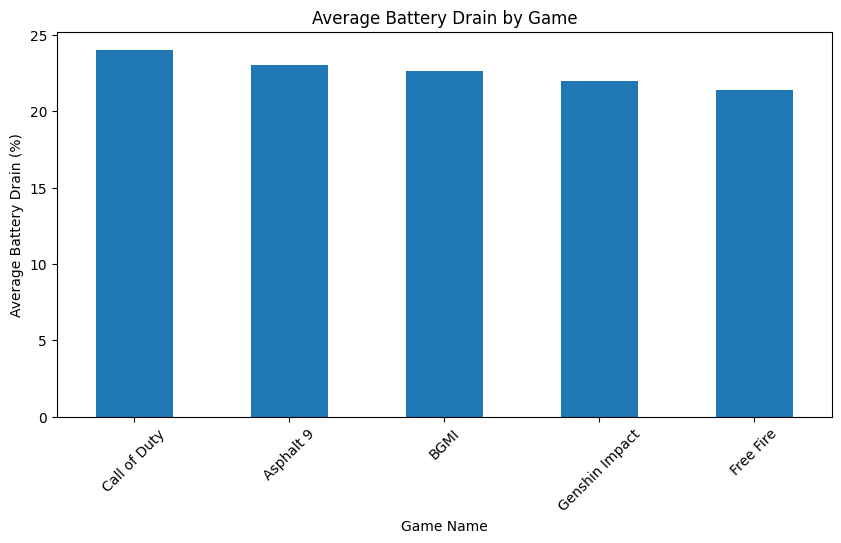

In [9]:
plt.figure(figsize=(10,5))
game_drain.plot(kind="bar")
plt.title("Average Battery Drain by Game")
plt.xlabel("Game Name")
plt.ylabel("Average Battery Drain (%)")
plt.xticks(rotation=45)
plt.show()

In [10]:
device_drain = df.groupby("Device_Type")["Battery_Drain_%"].mean().sort_values(ascending=False)
device_drain

Device_Type
Android    22.679764
iOS        22.486762
Name: Battery_Drain_%, dtype: float64

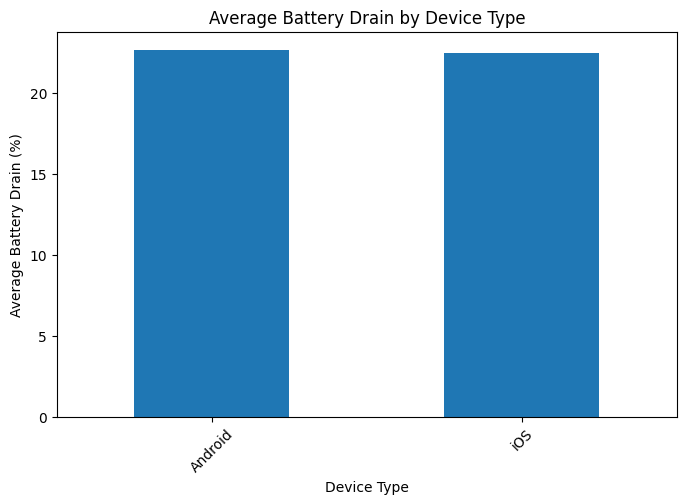

In [11]:
plt.figure(figsize=(8,5))
device_drain.plot(kind="bar")
plt.title("Average Battery Drain by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Battery Drain (%)")
plt.xticks(rotation=45)
plt.show()

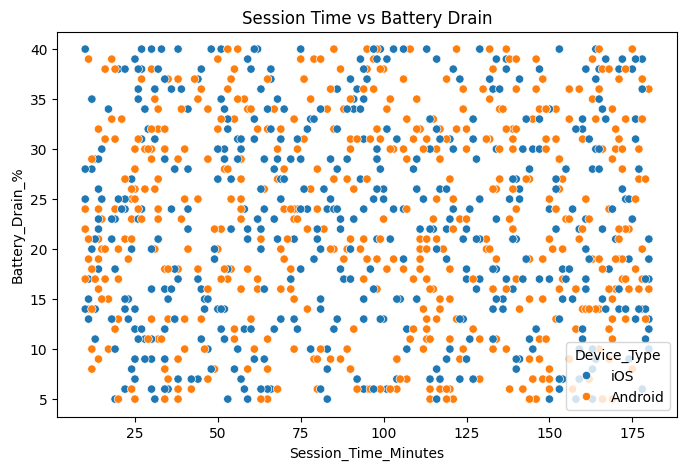

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Session_Time_Minutes", y="Battery_Drain_%", hue="Device_Type")
plt.title("Session Time vs Battery Drain")
plt.show()

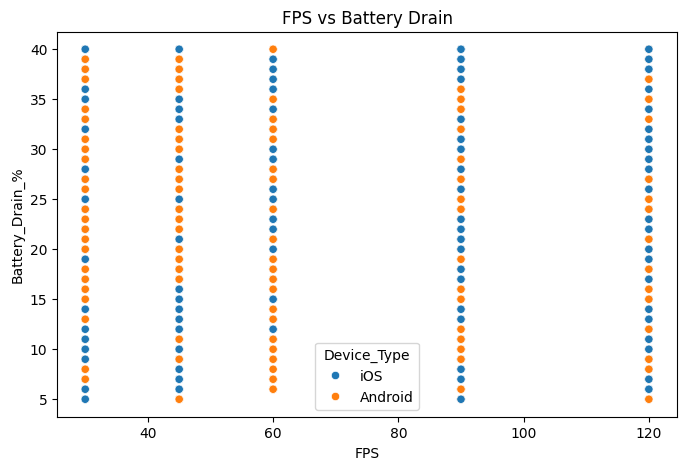

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="FPS", y="Battery_Drain_%", hue="Device_Type")
plt.title("FPS vs Battery Drain")
plt.show()

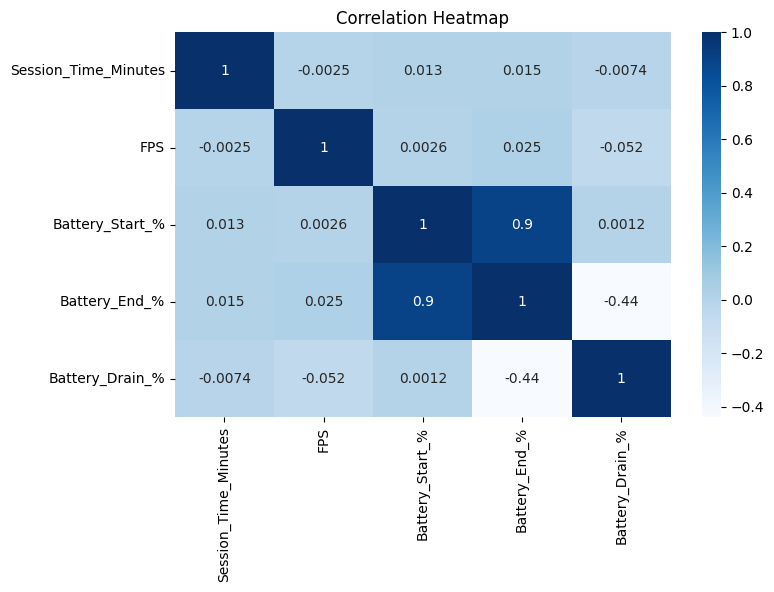

In [14]:
numeric_df = df[["Session_Time_Minutes", "FPS", "Battery_Start_%", "Battery_End_%", "Battery_Drain_%"]]

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
X = df[["Game_Name", "Device_Type", "Session_Time_Minutes", "FPS", "Battery_Start_%"]]
y = df["Battery_Drain_%"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
categorical_features = ["Game_Name", "Device_Type"]
numeric_features = ["Session_Time_Minutes", "FPS", "Battery_Start_%"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=42))
    ]
)

In [18]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [19]:
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 8.685653333333333
RMSE: 10.290542428311973
R2 Score: -0.09072574842185444


In [21]:
results = pd.DataFrame({
    "Actual Battery Drain": y_test,
    "Predicted Battery Drain": y_pred
})

results.head(10)

,Actual Battery Drain,Predicted Battery Drain
521,25,19.29
737,16,25.74
740,37,14.97
660,24,21.00
411,38,24.17
678,40,27.09
626,28,20.59
513,37,22.25
859,33,25.08
136,19,23.12


In [22]:
new_data = pd.DataFrame({
    "Game_Name": ["PUBG"],
    "Device_Type": ["Android"],
    "Session_Time_Minutes": [60],
    "FPS": [60],
    "Battery_Start_%": [90]
})

predicted_drain = model.predict(new_data)[0]
predicted_end_battery = new_data["Battery_Start_%"][0] - predicted_drain

print("Predicted Battery Drain:", predicted_drain)
print("Predicted Ending Battery:", predicted_end_battery)

Predicted Battery Drain: 23.31
Predicted Ending Battery: 66.69
